# Standalone ECG morphology preprocessing branch

**Purpose.** Extract and compare the project's distinct morphology
measurement families without prematurely merging them into one feature
matrix.

This notebook runs, displays, validates, and exports:

1. fixed published Varon five-QRS / 120-ms eigenvalues;
2. patient-average symmetric Varon width;
3. asymmetry-aware symmetric p95 Varon width;
4. patient-specific asymmetric pre/post-R Varon width;
5. fixed initial patient/lead whole-cycle templates with correlation,
   residual, derivative-DTW, and previous-beat change;
6. prominence P–QRS–T landmarks, intervals, amplitudes, area, and polarity.

Each output is saved separately. The notebook does **not** call three
Varon eigenvalue sets one final model, and none of the morphology values
is interpreted as seizure probability or artifact.

For five captured QRS rows in \(Q\), the fixed Varon core calculates
\(G=QQ^T\) and returns the five descending eigenvalues of \(G\).

## 1. Reproducible environment and data selection

This notebook is **independent of the other notebooks**. It locates the
project, imports the installed/tested branch package, selects one ECG
channel explicitly, creates its own output directory, and records the
runtime versions. The executable example uses MIT–BIH record 100,
channel `MLII`, starting at 0 s for 120 s.

Change only the configuration cell below to use another WFDB record.
For EDF data, use `ecg_cascade.edf.load_ecg_segment` after explicitly
inspecting and choosing the ECG channel.

#### Code walkthrough — imports, project discovery, and frozen run configuration

        **Why this cell exists.** Every later result depends on using the intended package, dataset, lead, units, and output folder.

        | Order | Code chunk | What executes | Why it is here |
        |---:|---|---|---|
        | 1 | Imports | Loads hashing, tables, numerical methods, plotting, NeuroKit, WFDB, and notebook display helpers. | The notebook needs both computation and visible audit evidence. |
| 2 | Project discovery | Searches the current directory and its parents for `pyproject.toml` and `src/ecg_cascade`, then places `src` on `sys.path`. | The same notebook must run from the repository root or its own folder without importing an unrelated installed copy. |
| 3 | Output contract | Creates one branch-specific directory under `outputs/standalone_notebooks`. | CSV, JSON, and manifests remain separate and reproducible. |
| 4 | Input configuration | Freezes record 100, lead MLII, start, duration, and patient identifier; the header assertion fails early if data are missing. | A clinical reader must know exactly which signal produced the figures. |
| 5 | Display configuration | Applies a consistent plot style and wide table display. | Successful runs should be readable without hidden columns or default styling ambiguity. |
| 6 | Version printout | Prints Python and dependency versions plus resolved paths. | A future rerun can distinguish data or code changes from environment changes. |

        **Evidence that the cell ran correctly**

        - A compact version block is printed with Python, NumPy, pandas, SciPy, NeuroKit2, and WFDB versions.
- `Project` resolves to the repository's `feature_extraction` folder and `Output` resolves to this branch's folder.
- No import, missing-file, or path assertion error appears.

        **If that evidence is absent, investigate**

        - A wrong working directory or a missing `feature_extraction/pyproject.toml`.
- The MIT–BIH dataset path or the requested lead name.
- A notebook kernel that is not using the project virtual environment.

        The code cell immediately below is the executable source of these outputs.
        Read the chunks in table order; statements inside a loop or function belong
        to the chunk that introduces that block.

In [1]:
from pathlib import Path
import hashlib
import json
import platform
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import neurokit2 as nk
import wfdb
from IPython.display import Code, Markdown, display

# Locate feature_extraction regardless of whether execution starts from
# the repository root, feature_extraction, or the notebook directory.
search_roots = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
PROJECT = next(
    path for path in search_roots
    if (path / "pyproject.toml").is_file()
    and (path / "src" / "ecg_cascade").is_dir()
)
ROOT = PROJECT.parent
SRC = PROJECT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

OUTPUT_DIR = PROJECT / "outputs" / "standalone_notebooks" / "morphology"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEMO_RECORD = (
    ROOT / "Datasets" / "mit-bih-arrhythmia-database-1.0"
    / "mit-bih-arrhythmia-database-1.0.0" / "100"
)
assert DEMO_RECORD.with_suffix(".hea").is_file(), DEMO_RECORD

RECORD_PATH = DEMO_RECORD       # WFDB path without extension
CHANNEL = "MLII"                # explicit lead choice
START_S = 0.0
DURATION_S = 120.0
PATIENT_ID = "mitdb_100"

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (12, 4.5),
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.labelcolor": "#304955",
    "text.color": "#203845",
})
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

print("Python:", platform.python_version())
print("NumPy:", np.__version__, "Pandas:", pd.__version__, "SciPy:", scipy.__version__)
print("NeuroKit2:", nk.__version__, "WFDB:", wfdb.__version__)
print("Project:", PROJECT)
print("Output:", OUTPUT_DIR)

Python: 3.12.10
NumPy: 2.4.2 Pandas: 2.3.3 SciPy: 1.17.0
NeuroKit2: 0.2.13 WFDB: 4.3.1
Project: C:\Users\Salam\Documents\ECGdetector\feature_extraction
Output: C:\Users\Salam\Documents\ECGdetector\feature_extraction\outputs\standalone_notebooks\morphology


#### Code walkthrough — load, validate, summarize, and preview the input ECG

        **Why this cell exists.** Algorithm outputs are interpretable only after the waveform, sampling rate, time coordinates, units, and finite-sample checks are visible.

        | Order | Code chunk | What executes | Why it is here |
        |---:|---|---|---|
        | 1 | Loader import | Imports the project's WFDB segment loader. | This centralizes channel lookup and physical-unit conversion instead of duplicating raw WFDB calls. |
| 2 | Segment read | Loads the configured lead and time range, then extracts samples and sampling frequency. | Every sample index used later must map to a physical time. |
| 3 | Time axis | Builds an absolute time vector from the segment start and sample rate. | Plots and event tables then share the same coordinate system. |
| 4 | Assertions | Requires one-dimensional, finite data and at least three seconds of signal. | Downstream filters and interval calculations should fail visibly rather than accept malformed input. |
| 5 | Summary | Prints source, lead, sampling rate, sample count, time span, and amplitude range. | This is the run's input provenance and first unit sanity check. |
| 6 | Preview figure | Plots the first 12 seconds of the unmodified physical ECG. | A reviewer can see polarity, gain, baseline, and recognizable beats before any branch operates. |

        **Evidence that the cell ran correctly**

        - The summary reports 360 Hz, the requested duration, finite amplitude limits, and channel MLII.
- The figure shows a continuous ECG trace with no blank panel or clipped time axis.
- The x-axis is seconds and the y-axis explicitly says physical WFDB units.

        **If that evidence is absent, investigate**

        - Lead selection, start/duration bounds, or a corrupt/missing WFDB pair.
- NaN/Inf samples, an unexpectedly flat trace, or an amplitude scale inconsistent with the header.
- A wrong sampling rate, because every millisecond conversion below depends on it.

        The code cell immediately below is the executable source of these outputs.
        Read the chunks in table order; statements inside a loop or function belong
        to the chunk that introduces that block.

{'source': 'C:\\Users\\Salam\\Documents\\ECGdetector\\Datasets\\mit-bih-arrhythmia-database-1.0\\mit-bih-arrhythmia-database-1.0.0\\100', 'channel': 'MLII', 'sampling_rate_hz': 360.0, 'samples': 43200, 'start_s': 0.0, 'duration_s': 120.0, 'minimum': -0.695, 'maximum': 1.125}


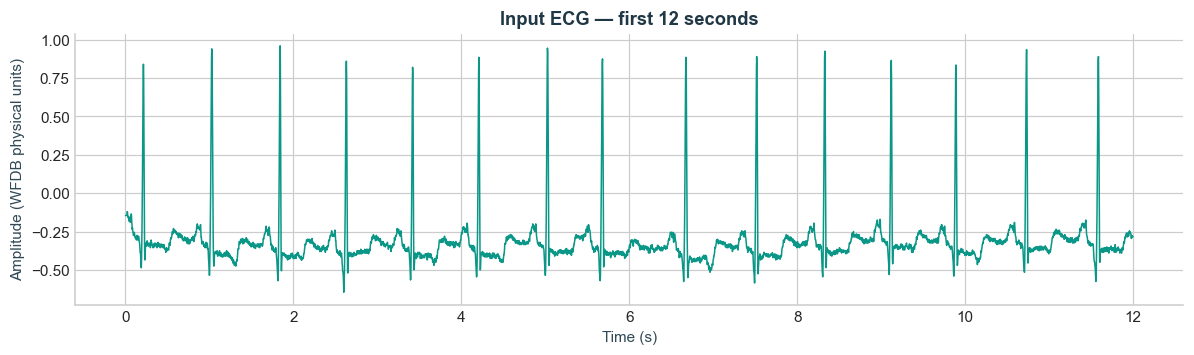

In [2]:
from ecg_cascade.wfdb_io import load_wfdb_segment

segment = load_wfdb_segment(
    RECORD_PATH,
    channel=CHANNEL,
    start_s=START_S,
    duration_s=DURATION_S,
)
ecg = segment.samples
fs = float(segment.sampling_rate_hz)
time_s = segment.start_s + np.arange(ecg.size) / fs

assert ecg.ndim == 1
assert np.all(np.isfinite(ecg))
assert ecg.size >= int(3 * fs)
print({
    "source": segment.record_path,
    "channel": segment.channel_name,
    "sampling_rate_hz": fs,
    "samples": int(ecg.size),
    "start_s": segment.start_s,
    "duration_s": segment.duration_s,
    "minimum": float(ecg.min()),
    "maximum": float(ecg.max()),
})

preview = time_s < time_s[0] + 12
fig, ax = plt.subplots(figsize=(13, 3.2))
ax.plot(time_s[preview], ecg[preview], color="#0b9787", lw=1.0)
ax.set(title="Input ECG — first 12 seconds", xlabel="Time (s)", ylabel="Amplitude (WFDB physical units)")
plt.show()

### Reproducibility rules used throughout

- No missing-sample imputation is performed.
- The selected channel and physical-unit scale are shown explicitly.
- Detector disagreement is context, not ground truth or artifact.
- All rolling windows are trailing/causal where the implementation says so.
- No notebook cell trains a seizure classifier or produces a clinical label.
- Tables are exported separately so intermediate measurements remain auditable.

## 2. Detect anchors once, then reuse the same track across morphology experiments

#### Code walkthrough — detect one anchor track and reuse it across morphology experiments

        **Why this cell exists.** Window-method comparisons are only fair when their R anchors are identical.

        | Order | Code chunk | What executes | Why it is here |
        |---:|---|---|---|
        | 1 | Cascade import/config | Runs the current two-track detector pipeline without inverted-context selection. | Anchor provenance stays explicit. |
| 2 | Track selection | Uses the NeuroKit lane for this demonstration and retains its events. | Every morphology row can be tied back to a named timestamp owner. |
| 3 | Fixed control | Retrieves the already calculated published 120-ms Varon result. | The unchanged control anchors all personalized-window comparisons. |
| 4 | Count print | Reports anchor and five-beat-window counts. | A short or failed run is obvious before expensive comparisons. |

        **Evidence that the cell ran correctly**

        - The printout contains more than 100 anchors and a nonzero fixed-Varon window count.
- All later methods receive the same `peaks` array.

        **If that evidence is absent, investigate**

        - Changing anchors between methods.
- Too few beats for five-beat windows.
- Treating the selected demonstration track as a validated final owner.

        The code cell immediately below is the executable source of these outputs.
        Read the chunks in table order; statements inside a loop or function belong
        to the chunk that introduces that block.

In [3]:
from ecg_cascade import NeuroKitZhaiConfig, run_neurokit_zhai_array

config = NeuroKitZhaiConfig(compute_inverted_context=False)
cascade = run_neurokit_zhai_array(ecg, fs, config=config)
track = cascade.selected.neurokit
peaks = track.detector.peak_samples
event_context = track.events
fixed_varon = track.morphology
print("NeuroKit anchors:", len(peaks), "Fixed Varon windows:", len(fixed_varon.features))

NeuroKit anchors: 148 Fixed Varon windows: 144


## 3. Obtain explicit calibration boundaries and P–QRS–T measurements

The demo uses the implemented prominence delineator to obtain calibration
boundaries. This is an **automatic research demonstration**, not manual
ground truth. In a causal patient-specific study, calibration must come
only from earlier data and its provenance must be retained.

#### Code walkthrough — derive explicit automatic QRS boundary calibration examples

        **Why this cell exists.** Personalized crops need measurable pre-R and post-R extents; using unnamed heuristics would make the comparison irreproducible.

        | Order | Code chunk | What executes | Why it is here |
        |---:|---|---|---|
        | 1 | Delineation | Runs the prominence P–QRS–T extractor on the shared anchors. | It supplies both interpretable morphology and candidate QRS boundaries. |
| 2 | Eligibility filter | Keeps the first 20 complete, physiologically ordered QRS complexes. | Incomplete or misordered landmarks must not calibrate a crop. |
| 3 | Boundary arithmetic | Converts onset-to-R, R-to-offset, and total QRS sample distances to milliseconds. | Personalized rules operate in physical time, not dataset-specific samples. |
| 4 | Assertions and summaries | Requires 20 positive durations and displays distributions plus delineation coverage. | Bad landmark order or insufficient calibration fails before morphology extraction. |

        **Evidence that the cell ran correctly**

        - The duration table shows 20 positive observations with plausible medians and ranges.
- The PQRST summary reports complete QRS and ordered-beat counts.

        **If that evidence is absent, investigate**

        - Automatic prominence failures, especially P/T endpoints.
- A sign error in onset/R/offset subtraction.
- Mistaking automatic calibration boundaries for manual ground truth.

        The code cell immediately below is the executable source of these outputs.
        Read the chunks in table order; statements inside a loop or function belong
        to the chunk that introduces that block.

In [4]:
from ecg_cascade.prominence_morphology import extract_prominence_morphology

pqrst = extract_prominence_morphology(
    ecg, peaks, fs,
    anchor_track="neurokit",
    patient_id=PATIENT_ID,
    lead_name=CHANNEL,
    segment_start_s=segment.start_s,
)
pf = pqrst.features
calibration = pf.loc[
    pf["complete_qrs"] & pf["physiological_order_valid"]
].head(20).copy()
before_ms = (
    calibration["r_peak_sample_in_segment"].to_numpy(float)
    - pd.to_numeric(calibration["qrs_onset_sample_in_segment"]).to_numpy(float)
) * 1000.0 / fs
after_ms = (
    pd.to_numeric(calibration["qrs_offset_sample_in_segment"]).to_numpy(float)
    - calibration["r_peak_sample_in_segment"].to_numpy(float)
) * 1000.0 / fs
total_ms = before_ms + after_ms
assert len(total_ms) == 20 and np.all(total_ms > 0)
display(pd.DataFrame({"onset_to_R_ms": before_ms, "R_to_offset_ms": after_ms, "QRS_total_ms": total_ms}).describe())
display(pd.Series(pqrst.summary(), name="prominence PQRST summary"))

,onset_to_R_ms,R_to_offset_ms,QRS_total_ms
count,20.000000,20.000000,20.000000
mean,30.972222,30.694444,61.666667
std,2.069888,1.906480,3.443595
min,27.777778,27.777778,58.333333
25%,30.555556,30.555556,60.416667
50%,30.555556,30.555556,61.111111
75%,31.250000,30.555556,61.111111
max,36.111111,36.111111,72.222222


anchor_track                                                               neurokit
beat_count                                                                      148
complete_qrs_count                                                              148
complete_qs_peak_count                                                          148
q_s_peak_order_pass_count                                                       148
complete_pqrst_count                                                            147
physiological_order_pass_count                                                  147
parameters                        {'method': 'emrich2024_prominence_via_neurokit...
seizure_probability_produced                                                  False
artifact_label_produced                                                       False
Name: prominence PQRST summary, dtype: object

## 4. Run every Varon window experiment separately

#### Code walkthrough — run four Varon crop experiments as separate lanes

        **Why this cell exists.** The project must learn which crop adds value; putting near-duplicate eigenvalue sets into one matrix would hide the ablation.

        | Order | Code chunk | What executes | Why it is here |
        |---:|---|---|---|
        | 1 | Imports | Loads mean-width, required-width, and asymmetric extractors. | Each method has a distinct geometric rule. |
| 2 | Mean symmetric | Uses the arithmetic mean total QRS duration centered on R. | This reproduces the original personalization proposal, including its known limitation. |
| 3 | p95 symmetric | Uses the 95th percentile of the width required to cover both sides. | It is the preferred one-number symmetric challenger from held-out boundary tests. |
| 4 | p95 asymmetric | Calibrates pre-R and post-R 95th percentiles separately with an explicit minimum sample size. | R is often not centered within QRS. |
| 5 | Named result map | Keeps fixed, mean, symmetric-p95, and asymmetric-p95 outputs distinct. | No matrix can accidentally imply they are four independent biological signals. |
| 6 | Summary | Reports realized crop, beat/window counts, defined Gram cores, and support context. | Coverage differences are visible before feature comparison. |

        **Evidence that the cell ran correctly**

        - Four method rows appear with nonzero beats/windows and defined five-eigenvalue cores.
- Pre/post widths differ for the asymmetric method and remain equal for symmetric methods.

        **If that evidence is absent, investigate**

        - A fallback caused by too few calibration beats.
- Crop boundaries outside the signal.
- Claims of seizure superiority—the case only demonstrates extraction and boundary behavior.

        The code cell immediately below is the executable source of these outputs.
        Read the chunks in table order; statements inside a loop or function belong
        to the chunk that introduces that block.

In [5]:
from ecg_cascade.morphology import (
    extract_patient_average_varon_morphology,
    extract_patient_asymmetric_varon_morphology,
    extract_patient_required_width_varon_morphology,
)

mean_symmetric = extract_patient_average_varon_morphology(
    ecg, peaks, fs, total_ms,
    anchor_track="neurokit", patient_id=PATIENT_ID, lead_name=CHANNEL,
    event_context=event_context,
)
p95_symmetric = extract_patient_required_width_varon_morphology(
    ecg, peaks, fs, before_ms, after_ms,
    anchor_track="neurokit", patient_id=PATIENT_ID, lead_name=CHANNEL,
    statistic="p95", event_context=event_context,
)
p95_asymmetric = extract_patient_asymmetric_varon_morphology(
    ecg, peaks, fs, before_ms, after_ms,
    anchor_track="neurokit", patient_id=PATIENT_ID, lead_name=CHANNEL,
    statistic="p95", minimum_calibration_beats=5,
    event_context=event_context,
)
varon_methods = {
    "fixed_120ms": fixed_varon,
    "patient_mean_symmetric": mean_symmetric,
    "patient_p95_symmetric": p95_symmetric,
    "patient_p95_asymmetric": p95_asymmetric,
}
summary_rows = []
for name, result in varon_methods.items():
    summary_rows.append({
        "method": name,
        "pre_R_ms": result.parameters["pre_r_ms_requested"],
        "post_R_ms": result.parameters["post_r_ms_requested"],
        "beats": len(result.beat_context),
        "windows": len(result.features),
        "defined": int(result.features["published_varon_core_defined"].sum()),
        "support_pass": int(result.features["support_context_pass"].sum()),
    })
varon_summary = pd.DataFrame(summary_rows).set_index("method")
display(varon_summary)

,pre_R_ms,post_R_ms,beats,windows,defined,support_pass
method,,,,,,
fixed_120ms,60.000000,60.000000,148,144,144,144
patient_mean_symmetric,30.833333,30.833333,148,144,144,144
patient_p95_symmetric,33.472222,33.472222,148,144,144,144
patient_p95_asymmetric,33.472222,33.472222,148,144,144,144


#### Code walkthrough — compare the same five beats under four capture rules

        **Why this cell exists.** A width number is abstract; aligned waveforms show exactly which pre/post-R signal each rule includes.

        | Order | Code chunk | What executes | Why it is here |
        |---:|---|---|---|
        | 1 | Window choice | Selects the same five-beat endpoint across all methods. | The visual comparison controls for beat identity. |
| 2 | Waveform slice | Uses each result's start/end beat indices to retrieve its five rows. | Displayed beats are exactly those used for the Gram matrix. |
| 3 | Method time axis | Builds a separate pre-R/post-R millisecond axis from realized sampling boundaries. | Different crop widths are plotted honestly. |
| 4 | Overlay | Draws five waveforms and a dashed R=0 reference in each panel. | Shape consistency and included margins are immediately visible. |

        **Evidence that the cell ran correctly**

        - A 2×2 figure appears with five traces in every panel.
- All R anchors align at 0 ms while panel widths differ according to the method summary.

        **If that evidence is absent, investigate**

        - Comparing different beat indices across methods.
- Using requested instead of realized sample widths.
- Reading display overlap as proof that eigenvalues improve seizure discrimination.

        The code cell immediately below is the executable source of these outputs.
        Read the chunks in table order; statements inside a loop or function belong
        to the chunk that introduces that block.

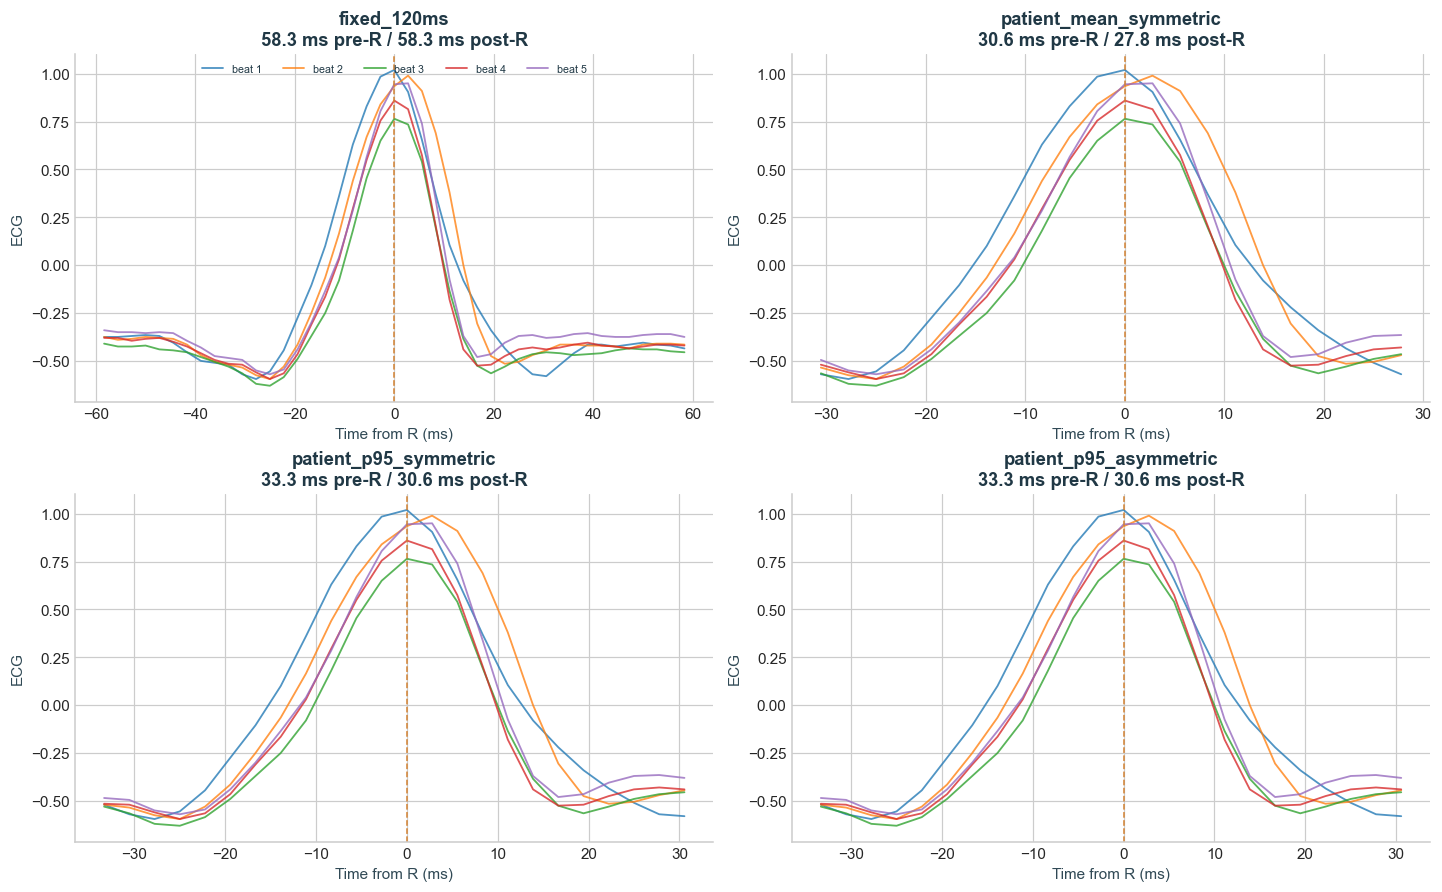

In [6]:
# Visualize the same five-beat window under each capture rule.
window_index = min(55, len(fixed_varon.features) - 1)
fig, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)
for ax, (name, result) in zip(axes.flat, varon_methods.items()):
    row = result.features.iloc[window_index]
    first, last = int(row.start_beat_index), int(row.end_beat_index)
    waveforms = result.beat_waveforms[first:last + 1]
    pre = float(result.parameters["pre_r_ms_realized"])
    post = float(result.parameters["post_r_ms_realized"])
    axis_ms = np.linspace(-pre, post, waveforms.shape[1])
    for beat_number, waveform in enumerate(waveforms, start=1):
        ax.plot(axis_ms, waveform, lw=1.2, alpha=.78, label=f"beat {beat_number}")
    ax.axvline(0, color="#d38232", ls="--", lw=1)
    ax.set(title=f"{name}\n{pre:.1f} ms pre-R / {post:.1f} ms post-R", xlabel="Time from R (ms)", ylabel="ECG")
axes[0, 0].legend(ncol=5, fontsize=7, loc="upper center")
plt.show()

## 5. Verify the fixed Varon Gram matrix and eigenvalues directly

#### Code walkthrough — reconstruct the published five-beat Gram eigenspectrum

        **Why this cell exists.** This is the mathematical core of the Varon lane and should be independently reproducible from the displayed five waveforms.

        | Order | Code chunk | What executes | Why it is here |
        |---:|---|---|---|
        | 1 | Five-beat matrix | Stacks the selected fixed-control waveforms as rows of Q. | The published construction operates on five captured QRS beats. |
| 2 | Gram matrix | Calculates `Q @ Q.T`. | Pairwise inner products encode shared waveform energy and similarity. |
| 3 | Symmetric eigensolver | Numerically symmetrizes the Gram matrix, computes eigenvalues, and reverses them to descending order. | The five lambdas form a stable ordered spectrum. |
| 4 | Stored-value test | Compares direct eigenvalues with the branch feature row. | Any normalization, centering, or ordering drift fails. |
| 5 | Heatmap and bars | Shows beat-to-beat Gram structure and the five energy modes. | The PI can connect the matrix to the numeric columns. |

        **Evidence that the cell ran correctly**

        - The heatmap is 5×5 and symmetric.
- Exactly five descending lambda bars appear.
- The direct/stored NumPy assertion passes.

        **If that evidence is absent, investigate**

        - Using columns instead of rows for beats.
- Unreported centering or normalization.
- Negative eigenvalues larger than tiny floating-point noise, which could indicate a malformed Gram matrix.

        The code cell immediately below is the executable source of these outputs.
        Read the chunks in table order; statements inside a loop or function belong
        to the chunk that introduces that block.

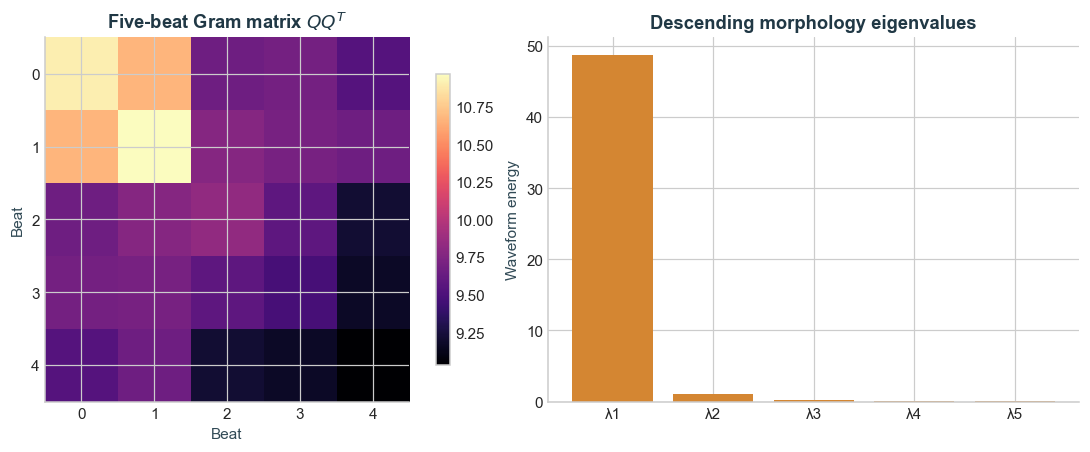

window_end_time_s            48.216667
complete_capture_fraction          1.0
detector_support_fraction          1.0
lambda1                      48.772971
lambda2                       1.007475
lambda3                       0.285055
lambda4                       0.132147
lambda5                       0.005952
Name: 55, dtype: object

In [7]:
row = fixed_varon.features.iloc[window_index]
q = fixed_varon.beat_waveforms[int(row.start_beat_index):int(row.end_beat_index) + 1]
gram = q @ q.T
direct_eigenvalues = np.linalg.eigvalsh(0.5 * (gram + gram.T))[::-1]
stored_eigenvalues = row[[f"lambda{i}" for i in range(1, 6)]].to_numpy(float)
np.testing.assert_allclose(direct_eigenvalues, stored_eigenvalues)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
image = axes[0].imshow(gram, cmap="magma")
axes[0].set(title=r"Five-beat Gram matrix $QQ^T$", xlabel="Beat", ylabel="Beat")
fig.colorbar(image, ax=axes[0], shrink=.8)
axes[1].bar([f"λ{i}" for i in range(1, 6)], direct_eigenvalues, color="#d48632")
axes[1].set(title="Descending morphology eigenvalues", ylabel="Waveform energy")
plt.show()
display(row[["window_end_time_s", "complete_capture_fraction", "detector_support_fraction", *[f"lambda{i}" for i in range(1, 6)]]])

## 6. Patient/lead initial-template morphology

Complete cycles are bounded by neighboring R-R midpoints. Pre-R and
post-R portions are resampled separately, baseline-centered, and L2
normalized. The first 20 complete cycles form a fixed template bank;
later cycles are evaluation rows. Returned values include template
correlation, normalized RMSE, raw residual RMS/energy, derivative-DTW
cost, warp fraction, and previous-beat shape change.

#### Code walkthrough — build a fixed initial patient/lead template bank and score later beats

        **Why this cell exists.** Varon measures five-beat energy geometry; template features answer the different question 'how unlike this patient's earlier beats is the current cycle?'.

        | Order | Code chunk | What executes | Why it is here |
        |---:|---|---|---|
        | 1 | Extractor import | Loads the tested patient-template branch. | The notebook orchestrates package code rather than maintaining a second implementation. |
| 2 | Template call | Uses the first 20 complete cycles as calibration and later cycles as evaluation. | Causal separation prevents a future beat from defining its own normal template. |
| 3 | Summary | Displays calibration, eligibility, and availability counts. | A missing or contaminated template bank is visible. |
| 4 | Feature preview | Shows correlation, normalized error, raw residuals, derivative-DTW, and previous-beat change for evaluation rows. | Each distance family retains its own meaning and units. |

        **Evidence that the cell ran correctly**

        - Twenty calibration members are reported and later evaluation rows exist.
- Evaluation feature values are finite and the preview distinguishes calibration from eligible rows.

        **If that evidence is absent, investigate**

        - Too few complete cycles.
- Calibration rows leaking into evaluation statistics.
- Calling template novelty a diagnosis; gain, ectopy, lead movement, and delineation error can all contribute.

        The code cell immediately below is the executable source of these outputs.
        Read the chunks in table order; statements inside a loop or function belong
        to the chunk that introduces that block.

In [8]:
from ecg_cascade.patient_template_morphology import extract_patient_template_morphology

template = extract_patient_template_morphology(
    ecg, peaks, fs,
    anchor_track="neurokit", patient_id=PATIENT_ID, lead_name=CHANNEL,
    calibration_beats=20, segment_start_s=segment.start_s,
)
display(pd.Series(template.summary(), name="template morphology summary"))
template_columns = [
    "anchor_time_s", "calibration_member", "evaluation_eligible",
    "template_correlation", "template_normalized_rmse",
    "template_raw_residual_rms", "template_raw_residual_energy",
    "template_derivative_dtw_cost", "template_dtw_warp_fraction",
    "previous_beat_normalized_rmse", "previous_beat_correlation",
]
display(template.features.loc[template.features["evaluation_eligible"], template_columns].head())

anchor_track                                                             neurokit
complete_midpoint_beat_count                                                  146
calibration_beat_count                                                         20
evaluation_beat_count                                                         126
template_count                                                                  1
template_member_counts                                                       [20]
waveform_shape                                                         [146, 192]
parameters                      {'method': 'patient_initial_median_midpoint_cy...
seizure_probability_produced                                                False
artifact_label_produced                                                     False
Name: template morphology summary, dtype: object

,anchor_time_s,calibration_member,evaluation_eligible,template_correlation,template_normalized_rmse,template_raw_residual_rms,template_raw_residual_energy,template_derivative_dtw_cost,template_dtw_warp_fraction,previous_beat_normalized_rmse,previous_beat_correlation
20,17.261111,False,True,0.994065,0.008302,0.021709,0.090486,0.002947,0.374468,0.009117,0.992759
21,18.130556,False,True,0.984365,0.013246,0.031975,0.196306,0.003696,0.434426,0.008723,0.992730
22,18.952778,False,True,0.992722,0.008721,0.021212,0.086388,0.002641,0.388186,0.016797,0.973259
23,19.738889,False,True,0.974913,0.016157,0.038194,0.280092,0.003189,0.381356,0.020507,0.960071
24,20.530556,False,True,0.944453,0.025222,0.082098,1.294102,0.003403,0.408333,0.033237,0.902934


#### Code walkthrough — visualize one evaluation cycle, its closest fixed template, and residual

        **Why this cell exists.** Correlation and RMSE become understandable when the two normalized shapes and their pointwise difference are shown.

        | Order | Code chunk | What executes | Why it is here |
        |---:|---|---|---|
        | 1 | Evaluation choice | Selects a later eligible cycle and reads its matched-template index. | The example cannot come from the calibration bank. |
| 2 | Normalized overlay | Plots the fixed template and evaluation waveform over 0–100% of the resampled cycle. | Timing is comparable despite different raw RR durations. |
| 3 | Residual | Subtracts template from evaluation and plots the difference around zero. | Residual amplitude shows where shape disagreement occurs. |

        **Evidence that the cell ran correctly**

        - The upper traces broadly overlap and the lower residual oscillates around zero.
- Labels clearly distinguish fixed template from evaluation beat.

        **If that evidence is absent, investigate**

        - An evaluation index outside the eligible set.
- A residual calculated in the opposite direction only if downstream sign matters.
- Confusing normalized residual with raw amplitude residual.

        The code cell immediately below is the executable source of these outputs.
        Read the chunks in table order; statements inside a loop or function belong
        to the chunk that introduces that block.

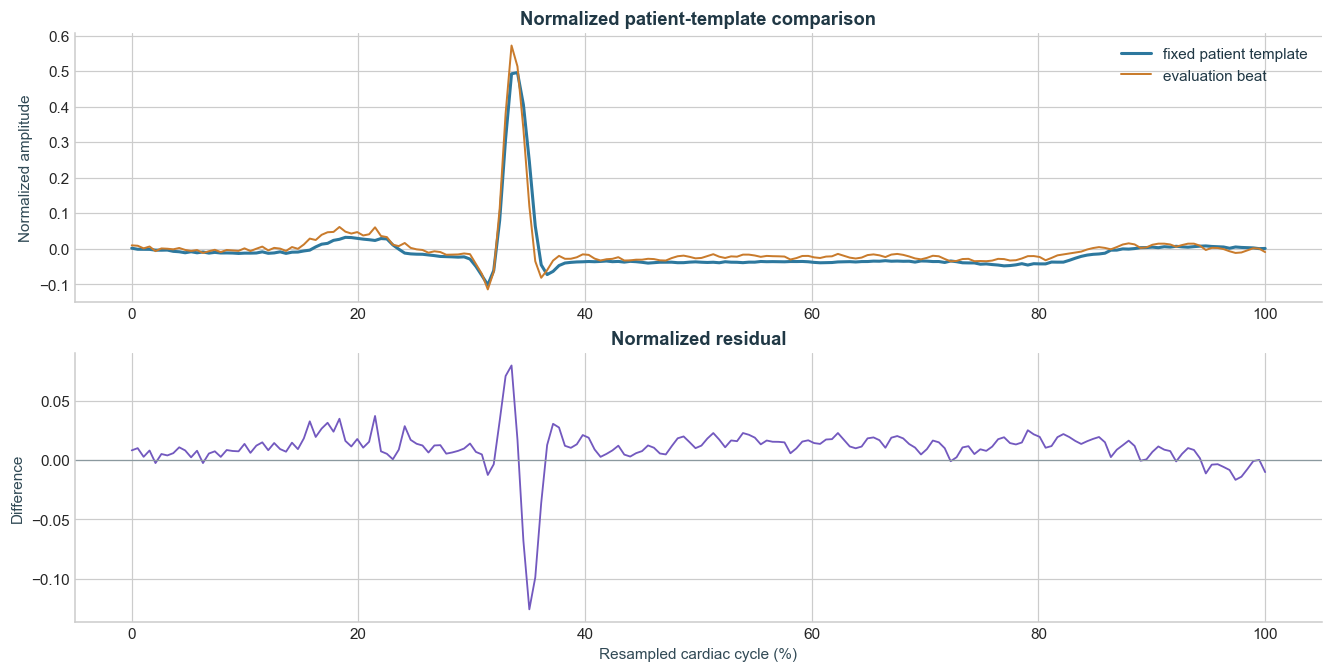

In [9]:
evaluation_index = int(np.flatnonzero(template.features["evaluation_eligible"].to_numpy(bool))[20])
matched_template = int(template.features.iloc[evaluation_index]["matched_template_index"])
x = np.linspace(0, 100, template.normalized_waveforms.shape[1])
fig, axes = plt.subplots(2, 1, figsize=(12, 6), constrained_layout=True)
axes[0].plot(x, template.normalized_template_bank[matched_template], lw=2.0, label="fixed patient template", color="#2d789e")
axes[0].plot(x, template.normalized_waveforms[evaluation_index], lw=1.3, label="evaluation beat", color="#c97b2c")
axes[0].set(title="Normalized patient-template comparison", ylabel="Normalized amplitude")
axes[0].legend()
residual = template.normalized_waveforms[evaluation_index] - template.normalized_template_bank[matched_template]
axes[1].plot(x, residual, color="#7359bf", lw=1.2)
axes[1].axhline(0, color="#8b999f", lw=.8)
axes[1].set(title="Normalized residual", xlabel="Resampled cardiac cycle (%)", ylabel="Difference")
plt.show()

## 7. Inspect P–QRS–T landmarks and interpretable measurements

#### Code walkthrough — annotate one P–QRS–T complex and display interpretable morphology columns

        **Why this cell exists.** Eigenvalues and template distances need interpretable companions such as QRS duration, amplitudes, area, and polarity.

        | Order | Code chunk | What executes | Why it is here |
        |---:|---|---|---|
        | 1 | Complete-beat choice | Selects a beat with all P/QRS/T landmarks in physiological order. | The example should not hide missing endpoints. |
| 2 | Landmark dictionary | Converts named sample columns to integer indices. | Every plotted marker is traceable to the exported table. |
| 3 | Local crop | Adds 80-ms context around P onset and T offset. | The full complex remains visible without plotting minutes of ECG. |
| 4 | Colored annotations | Groups P, QRS, and T landmarks with distinct colors and labels. | The screenshot teaches which boundaries generate each interval. |
| 5 | Measurement row | Displays durations, amplitudes, area, polarity, and completeness flags. | Visual and numeric morphology are linked for the same beat. |

        **Evidence that the cell ran correctly**

        - Nine ordered markers appear on one waveform.
- The feature row has finite QRS/P/QT values and both completeness/order flags are true.

        **If that evidence is absent, investigate**

        - Marker order violations or edge-clipped beats.
- Baseline definition when interpreting amplitudes/area.
- Treating automatic landmarks as cardiologist references.

        The code cell immediately below is the executable source of these outputs.
        Read the chunks in table order; statements inside a loop or function belong
        to the chunk that introduces that block.

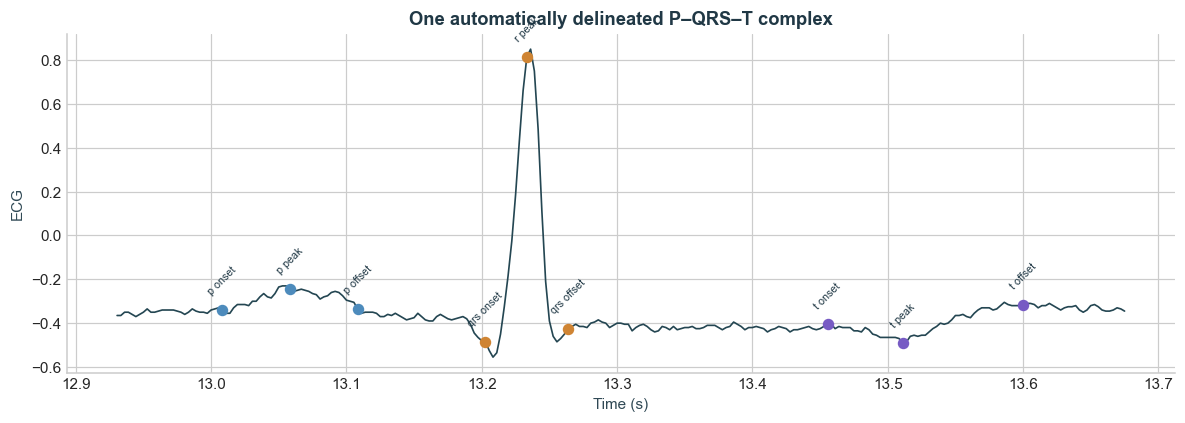

p_duration_ms                            100.0
pr_interval_ms                      194.444444
qrs_duration_ms                      61.111111
st_interval_ms                      191.666667
qt_interval_ms                      397.222222
p_peak_amplitude_from_baseline           0.135
r_anchor_amplitude_from_baseline         1.195
t_peak_amplitude_from_baseline           -0.11
qrs_peak_to_peak_amplitude               1.405
qrs_signed_area                       0.019792
qrs_polarity                          positive
complete_pqrst                            True
physiological_order_valid                 True
Name: 16, dtype: object

In [10]:
complete_indices = np.flatnonzero((pf["complete_pqrst"] & pf["physiological_order_valid"]).to_numpy(bool))
beat_index = int(complete_indices[min(15, len(complete_indices) - 1)])
beat = pf.iloc[beat_index]
landmark_columns = [
    "p_onset_sample_in_segment", "p_peak_sample_in_segment", "p_offset_sample_in_segment",
    "qrs_onset_sample_in_segment", "r_peak_sample_in_segment", "qrs_offset_sample_in_segment",
    "t_onset_sample_in_segment", "t_peak_sample_in_segment", "t_offset_sample_in_segment",
]
samples = {name: int(beat[name]) for name in landmark_columns}
first = max(0, samples["p_onset_sample_in_segment"] - int(.08 * fs))
last = min(ecg.size, samples["t_offset_sample_in_segment"] + int(.08 * fs))
fig, ax = plt.subplots(figsize=(13, 4))
local_time = np.arange(first, last) / fs
ax.plot(local_time, ecg[first:last], color="#244652", lw=1.1)
landmark_colors = ["#4d8bbc", "#4d8bbc", "#4d8bbc", "#cf8433", "#cf8433", "#cf8433", "#775bc4", "#775bc4", "#775bc4"]
for (name, sample), color in zip(samples.items(), landmark_colors):
    label = name.replace("_sample_in_segment", "").replace("_", " ")
    ax.scatter(sample / fs, ecg[sample], s=42, color=color, zorder=3)
    ax.annotate(label, (sample / fs, ecg[sample]), xytext=(0, 10), textcoords="offset points", ha="center", fontsize=7, rotation=45)
ax.set(title="One automatically delineated P–QRS–T complex", xlabel="Time (s)", ylabel="ECG")
plt.show()
display(beat[[
    "p_duration_ms", "pr_interval_ms", "qrs_duration_ms", "st_interval_ms", "qt_interval_ms",
    "p_peak_amplitude_from_baseline", "r_anchor_amplitude_from_baseline", "t_peak_amplitude_from_baseline",
    "qrs_peak_to_peak_amplitude", "qrs_signed_area", "qrs_polarity",
    "complete_pqrst", "physiological_order_valid"
]])

## 8. Case study — record 207 exposes morphology, polarity, and coverage

The all-48-record [morphology fidelity audit](../../docs/17_MORPHOLOGY_FIDELITY_AND_REVIEWER.md)
identified record 207 as a counterexample hidden by pooled results.
Its changing bundle-branch morphologies and polarity make waveform
alignment difficult. In the saved audit, NeuroKit's median absolute
matched-beat timing error reached 66.7 ms and strict five-beat coverage
fell to about 0.372, even though pooled NeuroKit timing was much better.

The [record-207 case report](../../reports/MITBIH_Record_207_Morphology_Polarity_Case_Analysis.pdf)
also found that original-polarity RR support was only 9.28% in the tested
architecture, while a dual-polarity context improved coverage—but the
project correctly refused to select polarity on the same record used to
demonstrate the gain.

The successful-run screenshot below is deliberately busy: it is a
reviewer, not a single-number dashboard. It keeps expert, NeuroKit,
UNSW/Khamis, Zhai, RR, and five-beat eigenvalue-energy context visible.

Paper links used by this branch:

- Varon et al. (2015), five-beat ECG morphology seizure features, [DOI 10.1016/j.jelectrocard.2015.08.020](https://doi.org/10.1016/j.jelectrocard.2015.08.020).
- Emrich et al. (2024), physiology-informed prominence delineation, [EUSIPCO paper](https://eurasip.org/Proceedings/Eusipco/Eusipco2024/pdfs/0001402.pdf).

#### Code walkthrough — display the prior record 207 morphology/polarity reviewer case

        **Why this cell exists.** Pooled averages hid a record where changing bundle-branch morphology and polarity produced large timestamp and five-beat-coverage errors.

        | Order | Code chunk | What executes | Why it is here |
        |---:|---|---|---|
        | 1 | Evidence paths | Locates the saved reviewer screenshot and all-48 morphology summary. | The case is tied to reproducible repository artifacts. |
| 2 | Existence checks | Fails if either evidence artifact is missing. | A notebook should never render a broken or substituted case silently. |
| 3 | Case metrics | Loads record 207 rows for the detector/feature-fidelity measures. | The screenshot is accompanied by quantitative context. |
| 4 | Screenshot display | Embeds the full multi-branch reviewer view in the executed notebook. | The user requested a visible correct-run example for PI demonstration. |

        **Evidence that the cell ran correctly**

        - The displayed case table includes record 207 and the screenshot shows ECG, four marker tracks, five-beat lambda energy, and RR.
- Expert misses and morphology/polarity changes remain visible rather than collapsed into one score.

        **If that evidence is absent, investigate**

        - A stale screenshot from another record/channel.
- Missing expert `.atr` context.
- Interpreting display-normalized lambda fractions as the raw eigenvalue columns used by the extractor.

        The code cell immediately below is the executable source of these outputs.
        Read the chunks in table order; statements inside a loop or function belong
        to the chunk that introduces that block.

,beat_f1,median_absolute_timing_error_ms,five_beat_window_coverage,median_raw_eigenvalue_relative_l1_error,median_exploratory_normalized_spectrum_l1_error
candidate_track,,,,,
unsw,0.9624,5.5556,0.9801,0.0029,0.0016
neurokit,0.8177,66.6667,0.3718,0.6339,0.0084
zhai,0.9513,2.7778,0.9429,0.0011,0.0007


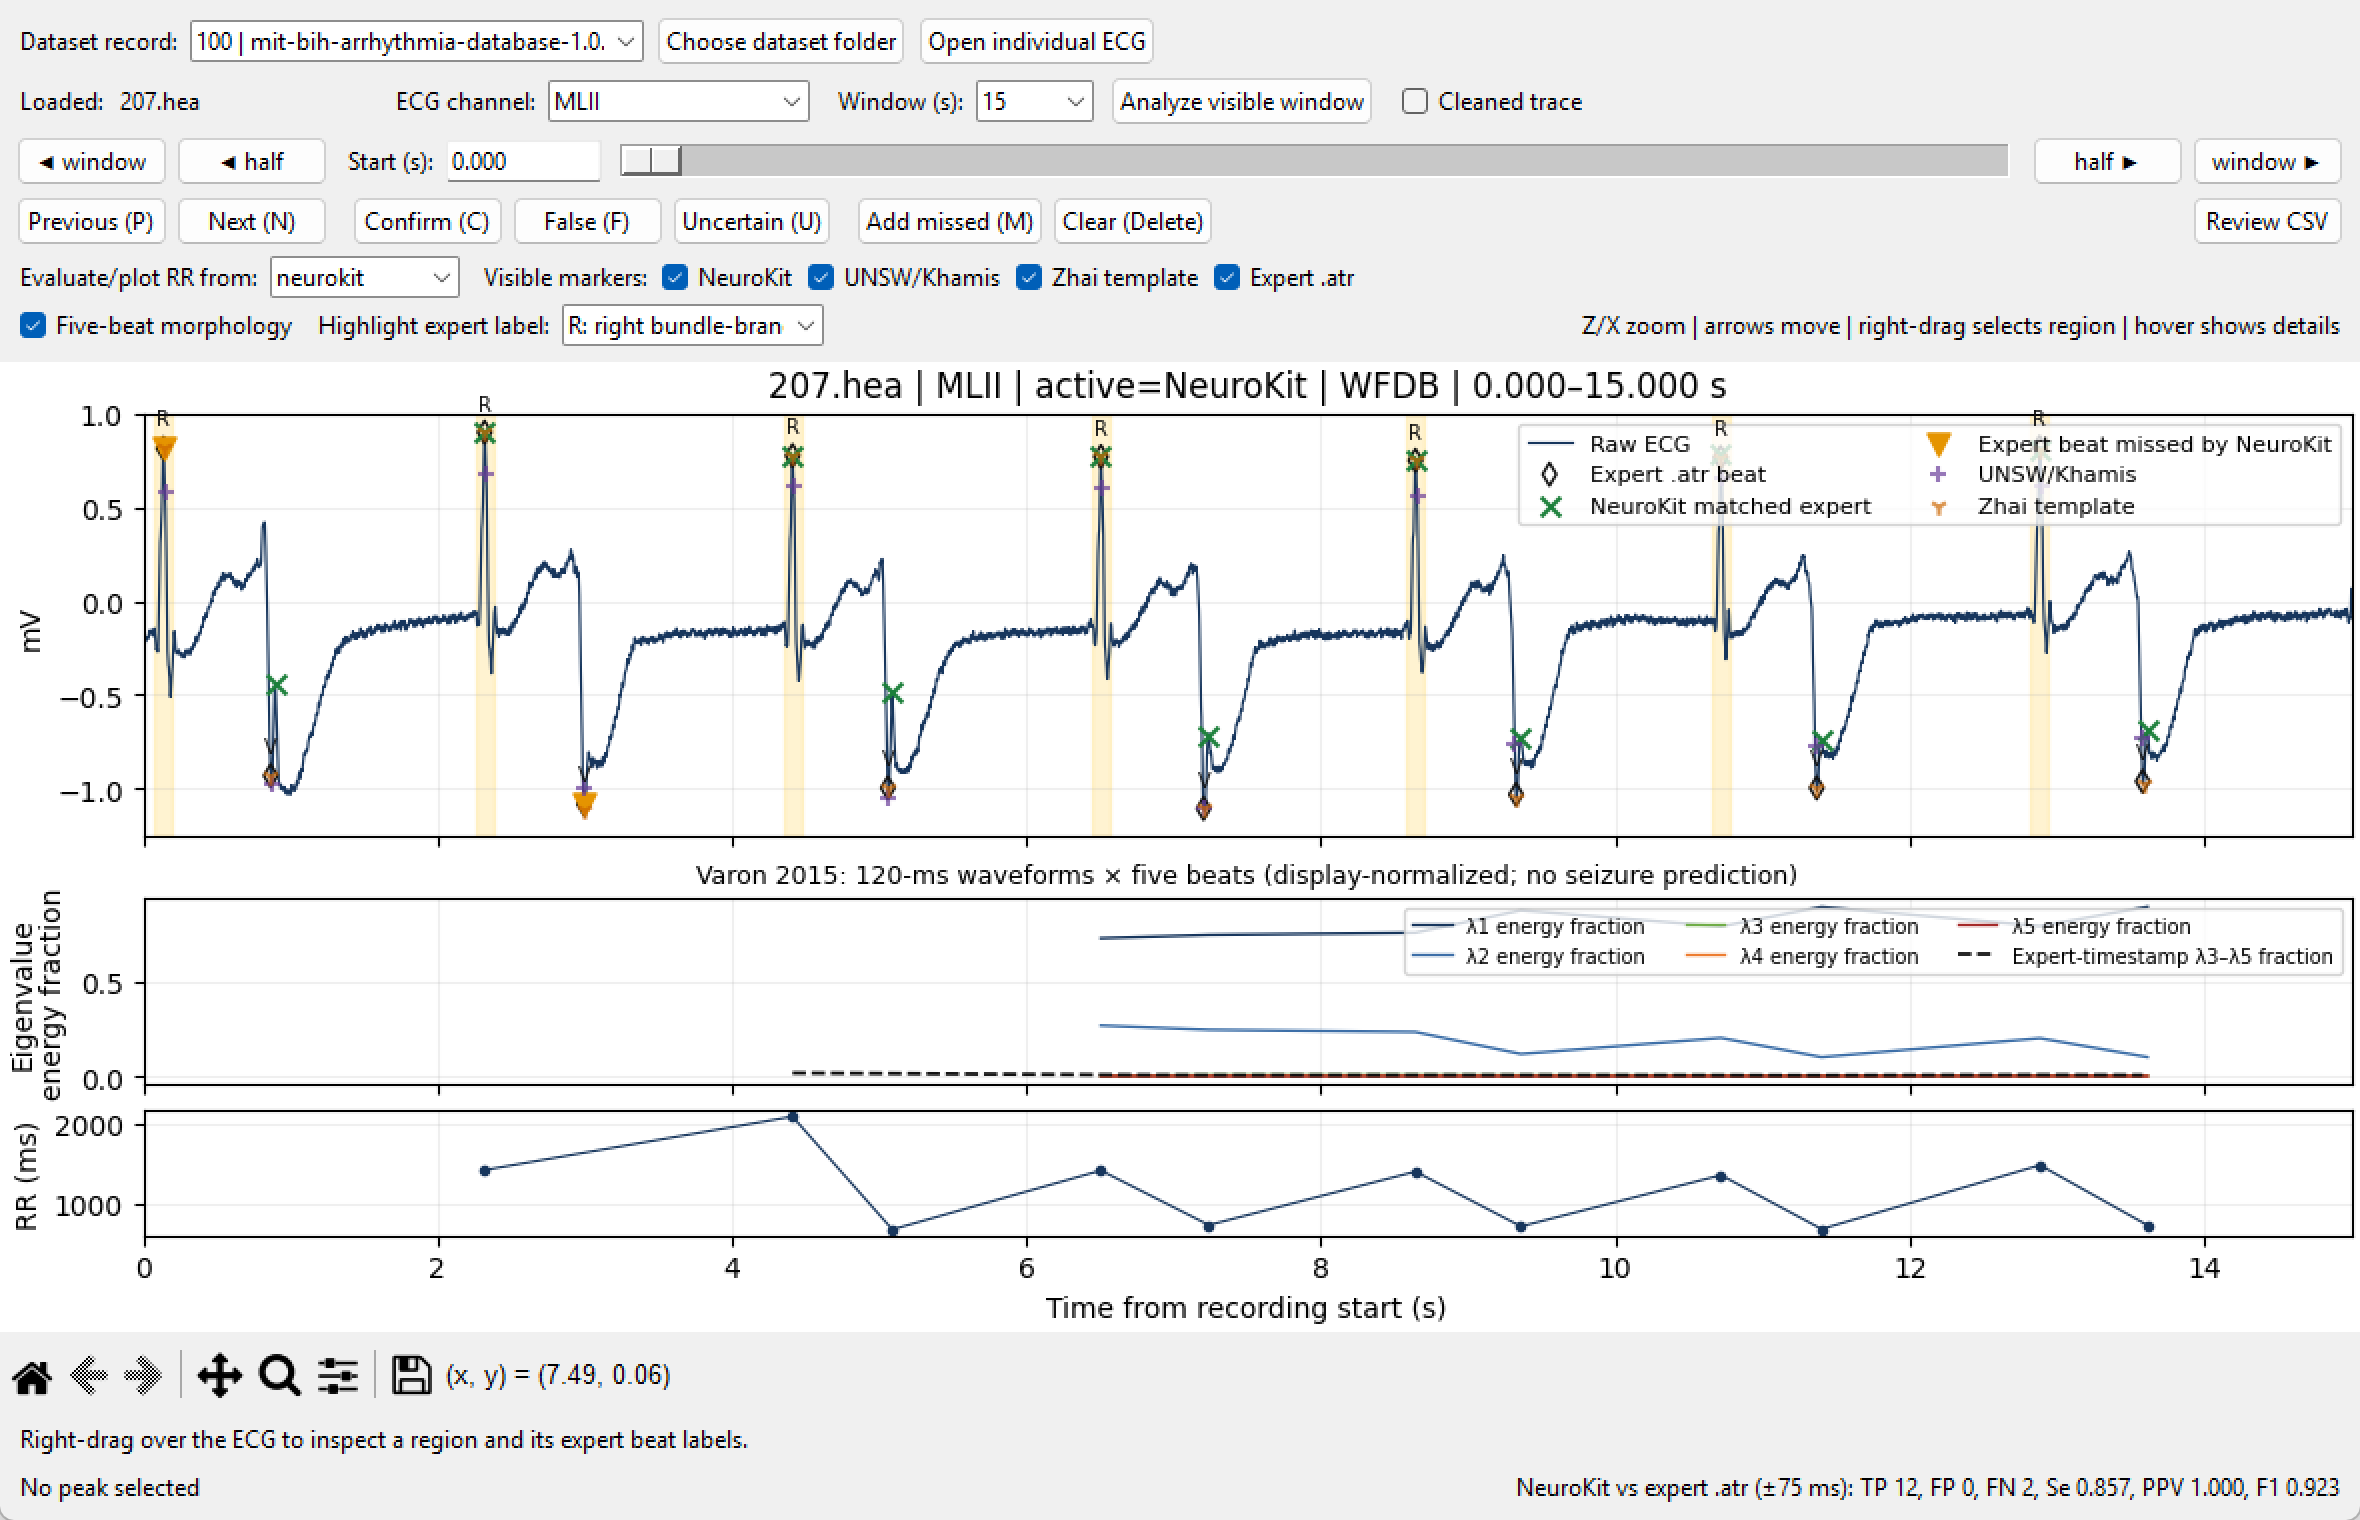

PASS — record 207 reviewer evidence and quantitative morphology-fidelity rows loaded.


In [11]:
from IPython.display import Image

CASE_SCREENSHOT = PROJECT / "outputs" / "ui_validation" / "record_207_branch_reviewer_full.png"
CASE_METRICS = PROJECT / "outputs" / "morphology_fidelity_all48_v1" / "record_summary.csv"
assert CASE_SCREENSHOT.is_file(), CASE_SCREENSHOT
assert CASE_METRICS.is_file(), CASE_METRICS

morphology_audit = pd.read_csv(CASE_METRICS)
morphology_case = morphology_audit.loc[
    morphology_audit["record_id"].astype(str) == "207",
    [
        "candidate_track", "beat_f1", "median_absolute_timing_error_ms",
        "five_beat_window_coverage", "median_raw_eigenvalue_relative_l1_error",
        "median_exploratory_normalized_spectrum_l1_error",
    ],
].set_index("candidate_track")
display(morphology_case.style.format("{:.4f}"))

assert morphology_case.loc["neurokit", "median_absolute_timing_error_ms"] > 60
assert morphology_case.loc["neurokit", "five_beat_window_coverage"] < 0.40
assert morphology_case.loc["zhai", "five_beat_window_coverage"] > 0.90

display(Image(filename=str(CASE_SCREENSHOT), width=1400))
print("PASS — record 207 reviewer evidence and quantitative morphology-fidelity rows loaded.")

### How to read the successful-run screenshot

1. **Top ECG panel:** black diamonds are expert beats; colored detector
   markers show where each algorithm placed an event. Orange downward
   triangles identify expert beats missed by the active NeuroKit lane.
2. **Middle morphology panel:** five curves are display-normalized
   lambda energy fractions for consecutive five-beat windows. They help
   compare patterns on one screen; exported raw `lambda1`–`lambda5`
   remain the paper-backed measurements.
3. **Bottom RR panel:** large alternating RR changes demonstrate how an
   extra or missed ventricular anchor propagates into timing features.
4. **Correct interpretation:** the screenshot demonstrates a difficult
   morphology/polarity case and a coverage–fidelity tradeoff. It does
   not show a seizure prediction, morphology diagnosis, or automatic
   polarity-selection rule.

## 9. Export every morphology family separately

#### Code walkthrough — export each morphology family without premature combination

        **Why this cell exists.** Ablation matrices require separable files for fixed/personalized Varon, templates, and PQRST measurements.

        | Order | Code chunk | What executes | Why it is here |
        |---:|---|---|---|
        | 1 | Varon loop | Writes one feature table per crop rule. | Near-duplicate eigenvalue sets remain named experiments. |
| 2 | Template export | Writes the per-cycle patient-template measurements. | Novelty features stay distinct from five-beat eigenvalues. |
| 3 | PQRST export | Writes interpretable landmarks and measurements. | Durations/amplitudes can be audited independently. |
| 4 | Row-count display | Reports each output's length. | Missing families or unexpected row loss are immediately visible. |

        **Evidence that the cell ran correctly**

        - Six separate CSV files appear and each displayed row count is positive.

        **If that evidence is absent, investigate**

        - A shared filename overwriting another method.
- Combining columns before a held-out ablation.
- Different row granularities—five-beat windows versus single beats/cycles—before joining.

        The code cell immediately below is the executable source of these outputs.
        Read the chunks in table order; statements inside a loop or function belong
        to the chunk that introduces that block.

In [12]:
exports = {}
for name, result in varon_methods.items():
    path = OUTPUT_DIR / f"{name}_varon_features.csv"
    result.features.to_csv(path, index=False)
    exports[path.name] = len(result.features)
template_path = OUTPUT_DIR / "patient_template_features.csv"
pqrst_path = OUTPUT_DIR / "prominence_pqrst_features.csv"
template.features.to_csv(template_path, index=False)
pf.to_csv(pqrst_path, index=False)
exports[template_path.name] = len(template.features)
exports[pqrst_path.name] = len(pf)
display(pd.Series(exports, name="rows exported").to_frame())

,rows exported
fixed_120ms_varon_features.csv,144
patient_mean_symmetric_varon_features.csv,144
patient_p95_symmetric_varon_features.csv,144
patient_p95_asymmetric_varon_features.csv,144
patient_template_features.csv,146
prominence_pqrst_features.csv,148


## 10. Notebook-level acceptance checks and limits

#### Code walkthrough — enforce morphology availability and scope guards

        **Why this cell exists.** The notebook must prove all requested families executed while preventing accidental seizure/artifact labels.

        | Order | Code chunk | What executes | Why it is here |
        |---:|---|---|---|
        | 1 | Varon checks | Requires a defined published core, lambda1–lambda5, and false classifier flags for every crop. | Each experiment must contain the same mathematical core and remain preprocessing-only. |
| 2 | Template checks | Requires eligible later cycles and finite correlations. | A template bank alone is not enough; it must score held-out-in-time cycles. |
| 3 | PQRST checks | Requires at least one complete QRS and no seizure output. | Interpretable morphology must actually be available. |

        **Evidence that the cell ran correctly**

        - The cell ends with `PASS — all morphology implementations executed and retained separate outputs.`

        **If that evidence is absent, investigate**

        - The named method/feature in the first failed assertion.
- Calibration completeness or crop bounds.
- Any new label/probability field added without a separately validated model.

        The code cell immediately below is the executable source of these outputs.
        Read the chunks in table order; statements inside a loop or function belong
        to the chunk that introduces that block.

In [13]:
for name, result in varon_methods.items():
    assert result.features["published_varon_core_defined"].any(), name
    assert all(f"lambda{i}" in result.features for i in range(1, 6)), name
    assert not result.features["seizure_probability_produced"].any(), name
    assert not result.features["artifact_label_produced"].any(), name
assert template.features["evaluation_eligible"].any()
assert np.isfinite(template.features.loc[template.features["evaluation_eligible"], "template_correlation"]).all()
assert pf["complete_qrs"].any()
assert not pf["seizure_probability_produced"].any()
print("PASS — all morphology implementations executed and retained separate outputs.")

PASS — all morphology implementations executed and retained separate outputs.


### Interpretation limits

- Automatic prominence boundaries are not manual landmark truth.
- Personalized calibration in this demo is derived from automatic earlier
  beats; a formal study must use a causal, independently validated split.
- Eigenvalues are amplitude-sensitive because unreported normalization is
  not added to the published Varon core.
- Template novelty can reflect physiology, ectopy, lead movement, gain,
  artifact, or landmark error. No cause is assigned.
- The final matrix should include only the selected Varon experiment after
  held-out comparison, not three nearly duplicated eigenvalue sets.

## Exact implementation appendix

To make the executed notebook a durable audit artifact, this section
embeds the **complete source text** of the modules used above and records
a SHA-256 digest for each file. The algorithms are imported from these
tested modules; they are not rewritten in a second, drifting notebook copy.

#### Code walkthrough — embed exact implementation source and cryptographic hashes

        **Why this cell exists.** A notebook can otherwise become an attractive but stale copy of production code; this cell records precisely what implementation was executed.

        | Order | Code chunk | What executes | Why it is here |
        |---:|---|---|---|
        | 1 | Source list | Freezes the branch modules and scripts included in the appendix. | The reader can audit the implementation boundary. |
| 2 | File loop | Reads every file as UTF-8, counts lines, and calculates SHA-256. | A one-character source change produces a different digest. |
| 3 | Rendered source | Displays the complete Python text in the executed notebook. | Every internal line remains reviewable without opening a second application. |
| 4 | Manifest export | Writes `source_manifest.json` and displays its table. | Automated checks can compare filenames, line counts, and hashes later. |

        **Evidence that the cell ran correctly**

        - Each expected module appears as a rendered code block with a 64-character SHA-256 digest.
- The final table contains one row per requested source file and positive line counts.
- `source_manifest.json` is saved in the branch output directory.

        **If that evidence is absent, investigate**

        - A source module that moved or is missing.
- An unexpected project root, which would hash the wrong files.
- Notebook size limits if a front end refuses to render the complete appendix.

        The code cell immediately below is the executable source of these outputs.
        Read the chunks in table order; statements inside a loop or function belong
        to the chunk that introduces that block.

In [14]:
SOURCE_FILES = ['src/ecg_cascade/morphology.py', 'src/ecg_cascade/patient_template_morphology.py', 'src/ecg_cascade/prominence_morphology.py', 'src/ecg_cascade/delineation_validation.py', 'src/ecg_cascade/neurokit_zhai.py']
source_manifest = []
for relative in SOURCE_FILES:
    path = PROJECT / relative
    text = path.read_text(encoding="utf-8")
    digest = hashlib.sha256(text.encode("utf-8")).hexdigest()
    source_manifest.append({"file": relative, "sha256": digest, "lines": len(text.splitlines())})
    display(Markdown(f"### `{relative}`  \nSHA-256: `{digest}` · {len(text.splitlines())} lines"))
    display(Code(text, language="python"))

source_manifest_path = OUTPUT_DIR / "source_manifest.json"
source_manifest_path.write_text(json.dumps(source_manifest, indent=2), encoding="utf-8")
display(pd.DataFrame(source_manifest))
print("Saved:", source_manifest_path)

### `src/ecg_cascade/morphology.py`  
SHA-256: `f7a1d85eba11b4ba475c257f4257f9a54b31a603678ae204aa342b866baca182` · 798 lines

"""Beat-aligned QRS morphology measurements for the ECG cascade.

The primary published seizure-specific core follows Varon et al. (2015):
extract a symmetric 120-ms waveform around every explicit timestamp, stack
five consecutive complexes, form ``Q @ Q.T``, and retain its five ordered
eigenvalues.  The earlier 2013 80-ms window remains reproducible only by
explicitly requesting ``pre_r_ms=40`` and ``post_r_ms=40``.

This module deliberately does not classify a morphology as seizure, artifact,
PVC, or bundle-branch block.  Detector support and template correlation are
carried beside the measurements as context and never delete a waveform.
"""

from __future__ import annotations

from dataclasses import dataclass, replace
from typing import Any

import numpy as np
import pandas as pd

from .peaks import orient_signal


@dataclass(frozen=True)
class VaronMorphologyResult:
    """One detector track's beat waveforms and five-beat PCA measurements."""

    anchor_track: str
    beat_waveforms: np.ndarray
    beat_context: pd.DataFrame
    features: pd.DataFrame
    parameters: dict[str, Any]

    def summary(self) -> dict[str, object]:
        defined = (
            int(self.features["published_varon_core_defined"].sum())
            if not self.features.empty
            else 0
        )
        support_pass = (
            int(self.features["support_context_pass"].sum())
            if not self.features.empty
            else 0
        )
        return {
            "anchor_track": self.anchor_track,
            "beat_count": int(self.beat_context.shape[0]),
            "complete_beat_waveform_count": int(
                self.beat_context["qrs_capture_complete"].sum()
            ),
            "five_beat_window_count": int(self.features.shape[0]),
            "defined_varon_window_count": defined,
            "support_context_pass_count": support_pass,
            "waveform_shape": list(self.beat_waveforms.shape),
            "parameters": self.parameters,
            "seizure_probability_produced": False,
            "artifact_label_produced": False,
        }


def extract_varon_morphology(
    ecg: np.ndarray,
    anchor_peak_samples: np.ndarray,
    sampling_rate_hz: float,
    *,
    anchor_track: str,
    segment_start_s: float = 0.0,
    orientation: str = "original",
    event_context: pd.DataFrame | None = None,
    pre_r_ms: float = 60.0,
    post_r_ms: float = 60.0,
    stack_beats: int = 5,
    reliable_support_coverage: float = 1.0,
) -> VaronMorphologyResult:
    """Extract the published five-QRS eigenvalue feature sequence.

    ``event_context`` may contain detector-agreement and Zhai-correlation
    fields.  These fields are summarized over each five-beat window but do not
    determine whether the eigenvalues are calculated.

    The paper describes PCA and explicitly shows the matrix ``Q @ Q.T``.  The
    implementation therefore uses that uncentered Gram matrix.  It does not
    add unreported per-beat centering or amplitude normalization.
    """

    signal = _validate_inputs(ecg, anchor_peak_samples, sampling_rate_hz)
    oriented = orient_signal(signal, orientation)
    peaks = np.unique(np.asarray(anchor_peak_samples, dtype=np.int64))
    if pre_r_ms <= 0 or post_r_ms <= 0:
        raise ValueError("pre_r_ms and post_r_ms must be positive")
    if stack_beats != 5:
        raise ValueError(
            "The paper-traceable Varon core requires exactly five beats; "
            "use a separate experimental function for other window sizes"
        )
    if not 0 <= reliable_support_coverage <= 1:
        raise ValueError("reliable_support_coverage must be between 0 and 1")

    symmetric_capture = bool(np.isclose(pre_r_ms, post_r_ms, rtol=0.0, atol=1e-12))
    if symmetric_capture:
        waveform_samples = max(
            3,
            int(np.rint((pre_r_ms + post_r_ms) * sampling_rate_hz / 1000.0)),
        )
        # A sampled symmetric window can have an even number of values.
        # Preserve 

### `src/ecg_cascade/patient_template_morphology.py`  
SHA-256: `213026a1cf1e2093c4e69b3d81fdd010ed052703dbf72960d15490a004fd0491` · 400 lines

"""Deterministic patient-calibrated whole-beat morphology measurements.

Each beat is bounded by the midpoints to the preceding and following R peaks.
The pre-R and post-R portions are resampled separately so the R anchor remains
at a fixed column without erasing the original RR timing stored elsewhere.
Only the first requested complete beats form the fixed patient/lead templates;
later beats are the causal evaluation rows.

This module extracts measurements.  It does not train a seizure classifier or
convert morphology novelty into an artifact or seizure label.
"""

from __future__ import annotations

from dataclasses import dataclass
from typing import Any

import numpy as np
import pandas as pd

from .peaks import orient_signal


@dataclass(frozen=True)
class PatientTemplateMorphologyResult:
    """Whole-beat waveforms, fixed templates, and per-beat distances."""

    anchor_track: str
    beat_waveforms: np.ndarray
    normalized_waveforms: np.ndarray
    raw_template: np.ndarray
    normalized_template: np.ndarray
    raw_template_bank: np.ndarray
    normalized_template_bank: np.ndarray
    template_member_counts: np.ndarray
    features: pd.DataFrame
    parameters: dict[str, Any]

    def summary(self) -> dict[str, object]:
        return {
            "anchor_track": self.anchor_track,
            "complete_midpoint_beat_count": int(self.features.shape[0]),
            "calibration_beat_count": int(
                self.features["calibration_member"].sum()
            ),
            "evaluation_beat_count": int(
                self.features["evaluation_eligible"].sum()
            ),
            "template_count": int(self.raw_template_bank.shape[0]),
            "template_member_counts": self.template_member_counts.tolist(),
            "waveform_shape": list(self.beat_waveforms.shape),
            "parameters": self.parameters,
            "seizure_probability_produced": False,
            "artifact_label_produced": False,
        }


def extract_patient_template_morphology(
    ecg: np.ndarray,
    anchor_peak_samples: np.ndarray,
    sampling_rate_hz: float,
    *,
    anchor_track: str,
    patient_id: str,
    lead_name: str,
    calibration_beats: int = 20,
    pre_r_points: int = 64,
    post_r_points: int = 128,
    dtw_band_fraction: float = 0.10,
    max_templates: int = 3,
    new_template_correlation_threshold: float = 0.90,
    segment_start_s: float = 0.0,
    orientation: str = "original",
) -> PatientTemplateMorphologyResult:
    """Build a fixed initial template and score complete later cardiac cycles.

    ``calibration_beats`` counts complete midpoint-bounded cycles, not raw R
    anchors.  The first and last R anchors cannot own complete cycles because
    one neighboring midpoint is unavailable.
    """

    signal = _validate_inputs(ecg, anchor_peak_samples, sampling_rate_hz)
    if not str(patient_id).strip():
        raise ValueError("patient_id must be non-empty")
    if not str(lead_name).strip():
        raise ValueError("lead_name must be non-empty")
    if calibration_beats < 1:
        raise ValueError("calibration_beats must be positive")
    if pre_r_points < 2 or post_r_points < 2:
        raise ValueError("pre_r_points and post_r_points must each be at least 2")
    if not 0 < dtw_band_fraction <= 1:
        raise ValueError("dtw_band_fraction must be in (0, 1]")
    if max_templates < 1:
        raise ValueError("max_templates must be positive")
    if not -1 <= new_template_correlation_threshold <= 1:
        raise ValueError("new_template_correlation_threshold must be in [-1, 1]")

    oriented = orient_signal(signal, orientation)
    peaks = np.unique(np.asarray(anchor_peak_samples, dtype=np.int64))
    waveform_points = pre_r_points + post_r_points
    raw_rows: list[np.ndarray] = []
    normalized_rows: list[np.ndarray] = []
    metadata: list[dict[str, object]] = []

    for peak_index in range(1, peaks.size - 1):
        previous_peak = int(peaks[peak_index - 1])
        peak

### `src/ecg_cascade/prominence_morphology.py`  
SHA-256: `13c614a1e2b7ea788647f66da9b8b279db09b638f8642fc96c2280044099baeb` · 378 lines

...

"""Manual ECG-delineation references and lead-controlled validation helpers.

This module is deliberately separate from the seizure feature pipeline.  It
answers whether P/QRS/T landmarks can be measured against manual references;
it does not produce seizure labels or silently promote a delineator into the
runtime morphology branch.
"""

from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Mapping

import neurokit2 as nk
import numpy as np
import wfdb

from .peaks import compare_peak_sequences
from .wfdb_io import load_wfdb_beat_annotations


LANDMARK_NAMES = (
    "p_onset",
    "p_peak",
    "p_offset",
    "qrs_onset",
    "r_peak",
    "qrs_offset",
    "t_onset",
    "t_peak",
    "t_offset",
)

_NEUROKIT_KEYS = {
    "p_onset": "ECG_P_Onsets",
    "p_peak": "ECG_P_Peaks",
    "p_offset": "ECG_P_Offsets",
    "qrs_onset": "ECG_R_Onsets",
    "qrs_offset": "ECG_R_Offsets",
    "t_onset": "ECG_T_Onsets",
    "t_peak": "ECG_T_Peaks",
    "t_offset": "ECG_T_Offsets",
}

_BEAT_SYMBOLS = {
    "N", "L", "R", "B", "A", "a", "J", "S", "V", "r", "F",
    "e", "j", "n", "E", "/", "f", "Q", "?",
}


@dataclass(frozen=True)
class ManualDelineationRecord:
    """One ECG lead with manual landmarks and explicit evaluation anchors."""

    dataset: str
    record_id: str
    record_path: str
    lead_name: str
    lead_index: int
    sampling_rate_hz: float
    samples: np.ndarray
    landmarks: Mapping[str, np.ndarray]
    anchor_samples: np.ndarray
    evaluation_anchor_indices: np.ndarray
    annotation_source: str

    @property
    def evaluation_anchor_samples(self) -> np.ndarray:
        return self.anchor_samples[self.evaluation_anchor_indices]


def load_ludb_delineation_record(
    dataset: str | Path,
    record_id: str,
    *,
    lead: str = "ii",
) -> ManualDelineationRecord:
    """Load one LUDB lead and its lead-specific cardiologist annotations."""

    dataset = Path(dataset).expanduser().resolve()
    record_path = dataset / str(record_id)
    header = wfdb.rdheader(str(record_path))
    lead_matches = [
        index
        for index, name in enumerate(header.sig_name)
        if str(name).casefold() == str(lead).casefold()
    ]
    if len(lead_matches) != 1:
        raise ValueError(
            f"{record_id}: lead {lead!r} matched {len(lead_matches)} signals; "
            f"available={header.sig_name}"
        )
    lead_index = lead_matches[0]
    record = wfdb.rdrecord(
        str(record_path), channels=[lead_index], physical=True
    )
    if record.p_signal is None:
        raise ValueError(f"{record_id}: no physical signal returned")
    samples = np.asarray(record.p_signal[:, 0], dtype=np.float64)
    annotation = wfdb.rdann(str(record_path), str(lead).casefold())
    landmarks = parse_ludb_annotations(annotation.sample, annotation.symbol)
    anchors = landmarks["r_peak"]
    return _build_record(
        dataset="ludb",
        record_id=str(record_id),
        record_path=record_path,
        lead_name=str(header.sig_name[lead_index]),
        lead_index=lead_index,
        sampling_rate_hz=float(header.fs),
        samples=samples,
        landmarks=landmarks,
        anchor_samples=anchors,
        evaluation_anchor_indices=np.arange(anchors.size, dtype=np.int64),
        annotation_source=f"{lead}.manual",
    )


def load_qtdb_delineation_record(
    dataset: str | Path,
    record_id: str,
    *,
    annotation_extension: str = "q1c",
    required_channel0: str | None = "MLII",
    anchor_tolerance_ms: float = 75.0,
) -> ManualDelineationRecord:
    """Load QTDB channel 0 and selected manual waveform annotations.

    QTDB manual annotations cover selected beats.  When a full ``atr`` stream
    exists, it supplies surrounding expert QRS anchors to the delineator; only
    anchors corresponding to manually delineated beats enter evaluation.
    """

    dataset = Path(dataset).expanduser().resolve()
    record_path = dataset / str(record_i

### `src/ecg_cascade/neurokit_zhai.py`  
SHA-256: `e1e257a757ee26b96a4e5acebd2d335a6390b8f391a70985a452baaadb5f7db9` · 675 lines

"""Independent NeuroKit and Zhai RR--HRV tracks.

This module implements the architecture selected for the next audit:

raw ECG -> NeuroKit detector -> NeuroKit RR/HRV
        +-> Zhai detector     -> Zhai RR/HRV

The detector outputs are compared but never averaged, majority-voted, or
spliced beat by beat.  The code also deliberately avoids the previous local
positive-amplitude R-fiducial refinement.
"""

from __future__ import annotations

from dataclasses import asdict, dataclass
from importlib.metadata import version
import json
from pathlib import Path

import numpy as np
import pandas as pd

from .config import NeuroKitZhaiConfig
from .edf import SignalSegment, load_ecg_segment
from .fusion import build_detector_association_table, build_fusion_ready_table
from .morphology import VaronMorphologyResult, extract_varon_morphology
from .peaks import DetectorRun, PeakAgreement, compare_peak_sequences, detect_neurokit_gradient
from .prsa_bprsa import PRSABPRSAResult, extract_prsa_bprsa_features
from .rr_hrv import extract_rr_hrv_windows
from .wfdb_io import WFDBSegment, load_wfdb_segment
from .zhai import ZhaiDetection, detect_zhai_template


@dataclass(frozen=True)
class TimestampTrackResult:
    """One detector's unmodified timestamps and downstream RR/HRV output."""

    name: str
    detector: DetectorRun
    events: pd.DataFrame
    rr_intervals: pd.DataFrame
    features: pd.DataFrame
    morphology: VaronMorphologyResult
    prsa_bprsa_context: PRSABPRSAResult
    fusion_ready: pd.DataFrame

    def summary(self) -> dict[str, object]:
        return {
            "name": self.name,
            "detector": self.detector.summary(),
            "event_count": int(self.events.shape[0]),
            "supported_event_count": int(self.events["qrs_supported"].sum()),
            "event_support_fraction": _finite_or_none(
                float(self.events["qrs_supported"].mean())
                if not self.events.empty
                else np.nan
            ),
            "rr_interval_count": int(self.rr_intervals.shape[0]),
            "supported_rr_count": int(self.rr_intervals["rr_supported"].sum()),
            "rr_support_fraction": _finite_or_none(
                float(self.rr_intervals["rr_supported"].mean())
                if not self.rr_intervals.empty
                else np.nan
            ),
            "defined_hrv_rows": int(self.features["feature_defined"].sum()),
            "reliable_hrv_rows": int(self.features["feature_reliable"].sum()),
            "morphology": self.morphology.summary(),
            "prsa_bprsa_context": self.prsa_bprsa_context.summary(),
            "fusion_ready_row_count": int(self.fusion_ready.shape[0]),
            "fusion_defined_row_count": int(
                self.fusion_ready["fusion_measurements_defined"].sum()
            ),
            "timestamp_adjustment": "none_detector_output_used_directly",
        }


@dataclass(frozen=True)
class NeuroKitZhaiOrientationResult:
    orientation: str
    neurokit: TimestampTrackResult
    zhai: TimestampTrackResult
    zhai_detection: ZhaiDetection
    support_agreement: PeakAgreement
    audit_agreement: PeakAgreement
    detector_associations: pd.DataFrame

    def summary(self) -> dict[str, object]:
        return {
            "orientation": self.orientation,
            "neurokit": self.neurokit.summary(),
            "zhai": self.zhai.summary(),
            "zhai_intermediates": self.zhai_detection.summary(),
            "support_tolerance_agreement": self.support_agreement.to_dict(),
            "audit_tolerance_agreement": self.audit_agreement.to_dict(),
            "detector_association_rows": int(self.detector_associations.shape[0]),
            "timestamp_owner": "unselected_pending_annotation_validation",
        }


@dataclass(frozen=True)
class NeuroKitZhaiResult:
    selected_orientation: str
    selected: NeuroKitZhaiOrientationResult
    orientations: dict[str, NeuroKitZhaiOrientationResult]
    config: NeuroKitZhaiConfi

,file,sha256,lines
0,src/ecg_cascade/morphology.py,f7a1d85eba11b4ba475c257f4257f9a54b31a603678ae2...,798
1,src/ecg_cascade/patient_template_morphology.py,213026a1cf1e2093c4e69b3d81fdd010ed052703dbf729...,400
2,src/ecg_cascade/prominence_morphology.py,13c614a1e2b7ea788647f66da9b8b279db09b638f8642f...,378
3,src/ecg_cascade/delineation_validation.py,02933b9885f5070e47d67e2789163b970642751296130e...,668
4,src/ecg_cascade/neurokit_zhai.py,e1e257a757ee26b96a4e5acebd2d335a6390b8f391a709...,675


Saved: C:\Users\Salam\Documents\ECGdetector\feature_extraction\outputs\standalone_notebooks\morphology\source_manifest.json
